# 03 · Interpretação, robustez no tempo e produção

**Roteiro**
1. O que o modelo aprendeu (SHAP, exato via TreeSHAP)
2. Efeitos dentro do mês na regressão logística (odds ratios)
3. Exemplos individuais: os "motivos" de cada cliente
4. Insights acionáveis
5. Robustez no tempo: dois testes fora do tempo
6. Probabilidade em campanhas novas: ajuste pela taxa esperada
7. Estabilidade das variáveis (PSI)
8. Demonstração: a lista de ligações
9. Como colocar em produção

In [1]:
import json
import warnings

warnings.filterwarnings("ignore", message="IProgress not found")

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from matplotlib.colors import LinearSegmentedColormap
from scipy.special import expit, logit
from sklearn.metrics import brier_score_loss

from bank_marketing import plots
from bank_marketing.config import MODELS_DIR, PERIOD, REPORTS_DIR, TARGET
from bank_marketing.data import load_dataset, split_oot, split_random
from bank_marketing.evaluation import group_auc, lift_at_k, paired_bootstrap, psi, save_metrics
from bank_marketing.explain import feature_contributions, reason_codes
from bank_marketing.features import feature_origin
from bank_marketing.models import BusinessRule, calibrate_to_rate, make_lgbm, make_lgbm_pooled, make_logistic
from bank_marketing.plots import BASELINE, BLUE, GRAY, INK_2, ORANGE
from bank_marketing.predict import score_batch

plots.apply_style()
pd.set_option("display.float_format", "{:.3f}".format)

df = load_dataset()
train, test = split_random(df)
model = joblib.load(MODELS_DIR / "model.joblib")
best_params = json.loads((MODELS_DIR / "best_params.json").read_text())

LABELS = {
    "poutcome": "resultado da campanha anterior",
    "housing": "crédito imobiliário",
    "loan": "empréstimo pessoal",
    "contact": "canal de contato",
    "balance": "saldo médio anual",
    "age": "idade",
    "job": "profissão",
    "education": "escolaridade",
    "marital": "estado civil",
    "pdays": "dias desde o último contato",
    "previous": "contatos anteriores",
    "contacted_before": "já contatado antes",
    "default": "crédito em inadimplência",
}

## 1. O que o modelo aprendeu

O LightGBM calcula valores SHAP **exatos** (TreeSHAP, `pred_contrib=True`). Eles decompõem o score de cada
cliente, isto é, o desvio em log-odds em relação à média do mês, em contribuições que somam exatamente ao
score. Somamos as colunas one-hot de cada variável original (SHAP é aditivo) para medir a importância de cada
variável como um todo.

marital            0.110
balance            0.091
poutcome           0.077
housing            0.062
contact            0.050
pdays              0.045
age                0.024
loan               0.021
education          0.021
job                0.005
previous           0.002
contacted_before   0.000
default            0.000
Name: mean_abs_shap, dtype: float64

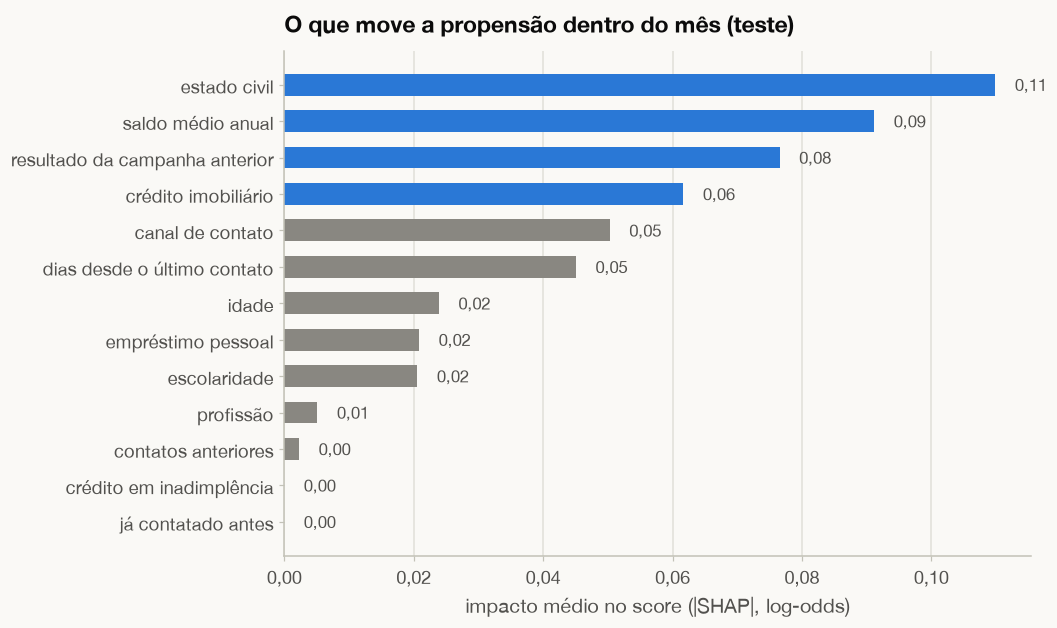

In [2]:
contribs = feature_contributions(model, test)
importance = contribs.drop(columns="bias").abs().mean().sort_values()
fig, ax = plots.new_figure(9.5, 5.6)
colors = [BLUE if v >= importance.iloc[-4] else GRAY for v in importance]
ax.barh([LABELS[v] for v in importance.index], importance, color=colors, height=0.6)
for i, v in enumerate(importance):
    ax.text(v + 0.003, i, plots.fmt_num(v, 2), va="center", fontsize=11, color=INK_2)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
plots.decimal_axis(ax, "x", 2)
ax.set_xlabel("impacto médio no score (|SHAP|, log-odds)")
ax.set_title("O que move a propensão dentro do mês (teste)")
plots.save(fig, "int_importancia")
importance.sort_values(ascending=False).rename("mean_abs_shap")

**Importância média** (quanto cada variável move o score, em média, no teste):
- lideram **estado civil**, **saldo**, **resultado da campanha anterior**, **crédito imobiliário**, **canal**
  e **pdays**;
- **profissão** e **idade** pesam pouco depois de controlar a época, coerente com o paradoxo de Simpson do
  notebook 01.

A importância média favorece variáveis que afetam *todo mundo* um pouco, como o estado civil. O sucesso
anterior atinge só 3% dos clientes, mas com efeito enorme (tabela a seguir).

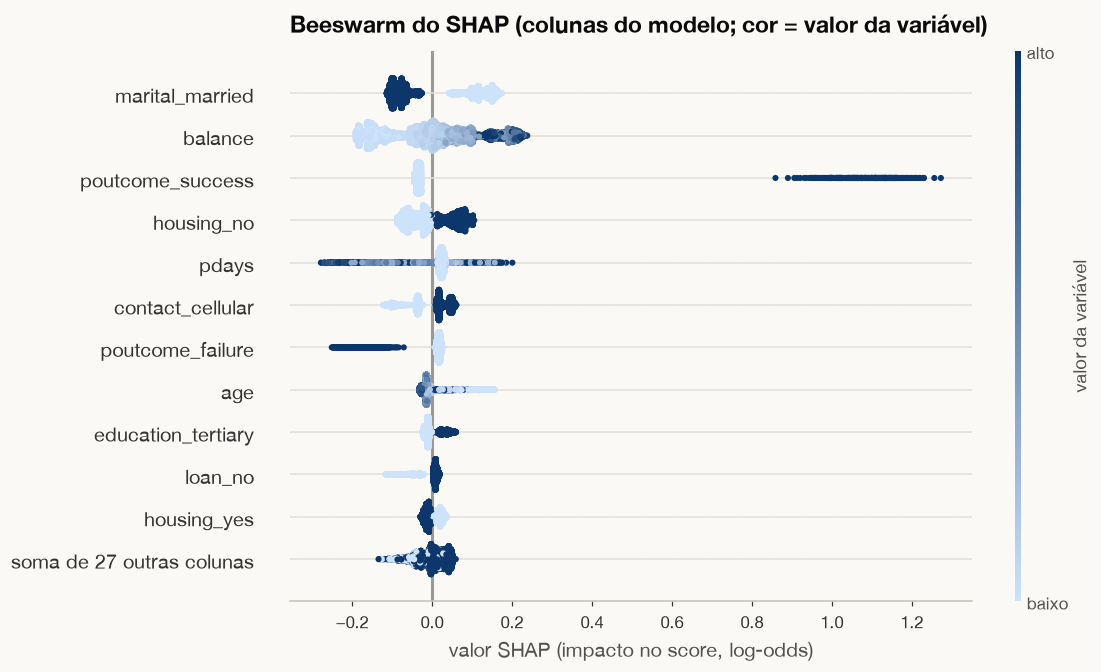

In [3]:
raw = model.contributions(test)
Xt = model.preprocessor_.transform(test)
explanation = shap.Explanation(values=raw.drop(columns="bias").to_numpy(), base_values=raw["bias"].to_numpy(),
                               data=Xt.to_numpy(), feature_names=list(Xt.columns))
cmap = LinearSegmentedColormap.from_list("blue_ramp", [plots.BLUE_RAMP[0], plots.BLUE_RAMP[-1]])
shap.plots.beeswarm(explanation, max_display=12, color=cmap, show=False, plot_size=(10, 6.5))
fig = plt.gcf()
ax_bee, ax_bar = fig.axes[0], fig.axes[-1]
ax_bee.set_title("Beeswarm do SHAP (colunas do modelo; cor = valor da variável)", loc="left")
ax_bee.set_xlabel("valor SHAP (impacto no score, log-odds)")
ax_bee.set_yticks(ax_bee.get_yticks(), [t.get_text().replace("Sum of", "soma de").replace("other features", "outras colunas")
                                        for t in ax_bee.get_yticklabels()])
ax_bar.set_ylabel("valor da variável")
ax_bar.set_yticks(ax_bar.get_yticks(), ["baixo" if t.get_text() == "Low" else "alto" if t.get_text() == "High" else t.get_text()
                                        for t in ax_bar.get_yticklabels()])
plots.save(fig, "int_beeswarm")
plt.show()

In [4]:
direction = {}
for var in ["poutcome", "housing", "loan", "contact", "education", "marital"]:
    by_cat = contribs[var].groupby(test[var]).mean()
    for cat, v in by_cat.items():
        direction[f"{var} = {cat}"] = {"contribuição média (log-odds)": v, "multiplicador de chance": np.exp(v),
                                       "n": int((test[var] == cat).sum())}
pd.DataFrame(direction).T.sort_values("contribuição média (log-odds)", ascending=False)

,contribuição média (log-odds),multiplicador de chance,n
poutcome = success,1.103,3.012,306.000
marital = divorced,0.139,1.150,1037.000
marital = single,0.136,1.146,2563.000
housing = no,0.072,1.074,4095.000
contact = cellular,0.038,1.038,5820.000
education = tertiary,0.036,1.037,2707.000
loan = no,0.012,1.012,7612.000
education = secondary,-0.007,0.993,4641.000
poutcome = nonexistent,-0.008,0.992,7370.000
education = unknown,-0.015,0.986,375.000


**O ajuste do mês em ação.** O mesmo LightGBM treinado sem o ajuste (todos os meses juntos) usa variáveis
ligadas à época como atalho:

,sem ajuste do mês,com ajuste do mês,razão
contact,0.312,0.050,6.198
housing,0.170,0.062,2.760
poutcome,0.132,0.077,1.719
balance,0.105,0.091,1.148
marital,0.090,0.110,0.823
age,0.090,0.024,3.781
pdays,0.057,0.045,1.255
loan,0.043,0.021,2.069
education,0.023,0.021,1.110
previous,0.011,0.002,4.669


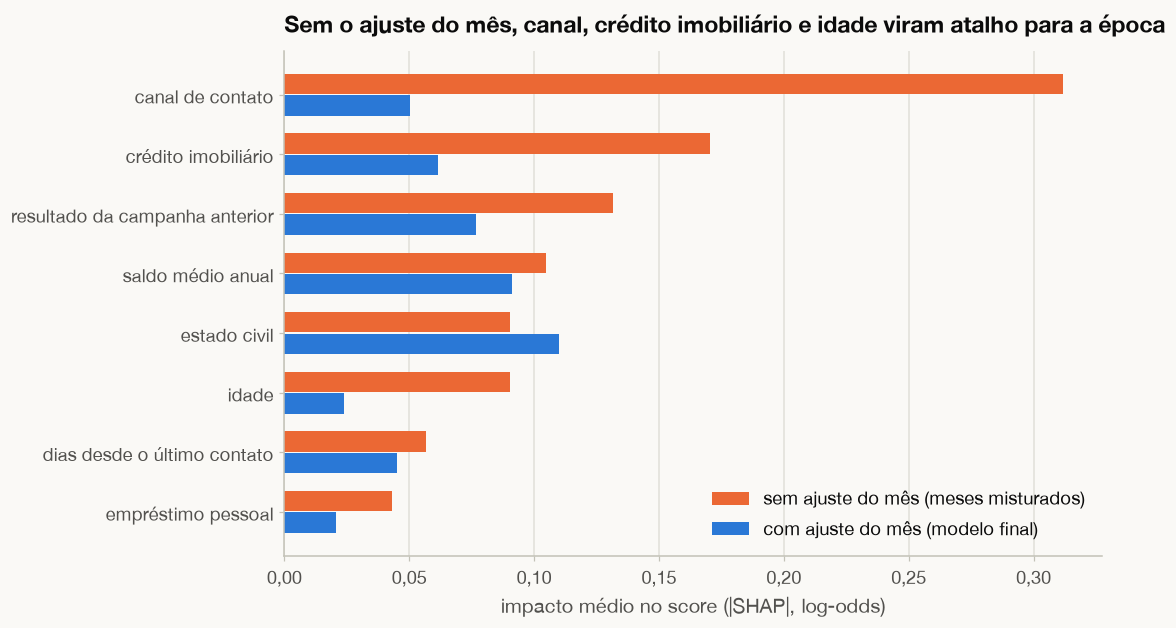

In [5]:
pooled_model = make_lgbm_pooled(**best_params).fit(train, train[TARGET])
Xp = pooled_model[0].transform(test)
pooled_contrib = pd.DataFrame(pooled_model[-1].predict(Xp, pred_contrib=True)[:, :-1], columns=Xp.columns)
pooled_importance = pooled_contrib.T.groupby(feature_origin(pooled_model[0])).sum().T.abs().mean()
compare = pd.DataFrame({"sem ajuste do mês": pooled_importance, "com ajuste do mês": importance}).sort_values(
    "sem ajuste do mês", ascending=False)
compare["razão"] = compare["sem ajuste do mês"] / compare["com ajuste do mês"]

fig, ax = plots.new_figure(10, 5.6)
top = compare.head(8).iloc[::-1]
y_pos = np.arange(len(top))
ax.barh(y_pos + 0.18, top["sem ajuste do mês"], height=0.34, color=ORANGE, label="sem ajuste do mês (meses misturados)")
ax.barh(y_pos - 0.18, top["com ajuste do mês"], height=0.34, color=BLUE, label="com ajuste do mês (modelo final)")
ax.set_yticks(y_pos, [LABELS[v] for v in top.index])
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
plots.decimal_axis(ax, "x", 2)
ax.set_xlabel("impacto médio no score (|SHAP|, log-odds)")
ax.set_title("Sem o ajuste do mês, canal, crédito imobiliário e idade viram atalho para a época")
ax.legend(loc="lower right")
plots.save(fig, "int_shap_ajuste")
compare

Sem o ajuste, o modelo passa a usar como atalho para a época:
- o **canal**, com peso **~6,2× maior**, porque o "não registrado" marca mai–jun/2008;
- o **crédito imobiliário** (~2,8×);
- a **idade** (~3,8×).

São exatamente os "efeitos de perfil" que o paradoxo de Simpson do notebook 01 mostrou serem época. Esta é a
principal razão para o ajuste: a ordenação fica parecida (notebook 02 e seção 5), mas o modelo final não
aprende o atalho.

**Direções dentro do mês** (contribuição média por categoria; `exp` = multiplicador aproximado da chance):
- sucesso anterior **+1,10 log-odds (~3,0×)**;
- fracasso anterior 0,78×;
- solteiros e divorciados ~1,15× vs. casados 0,91×;
- sem crédito imobiliário 1,07× vs. com crédito 0,95×;
- empréstimo pessoal 0,94×;
- celular 1,04× vs. fixo 0,91× vs. canal não registrado 0,93×.

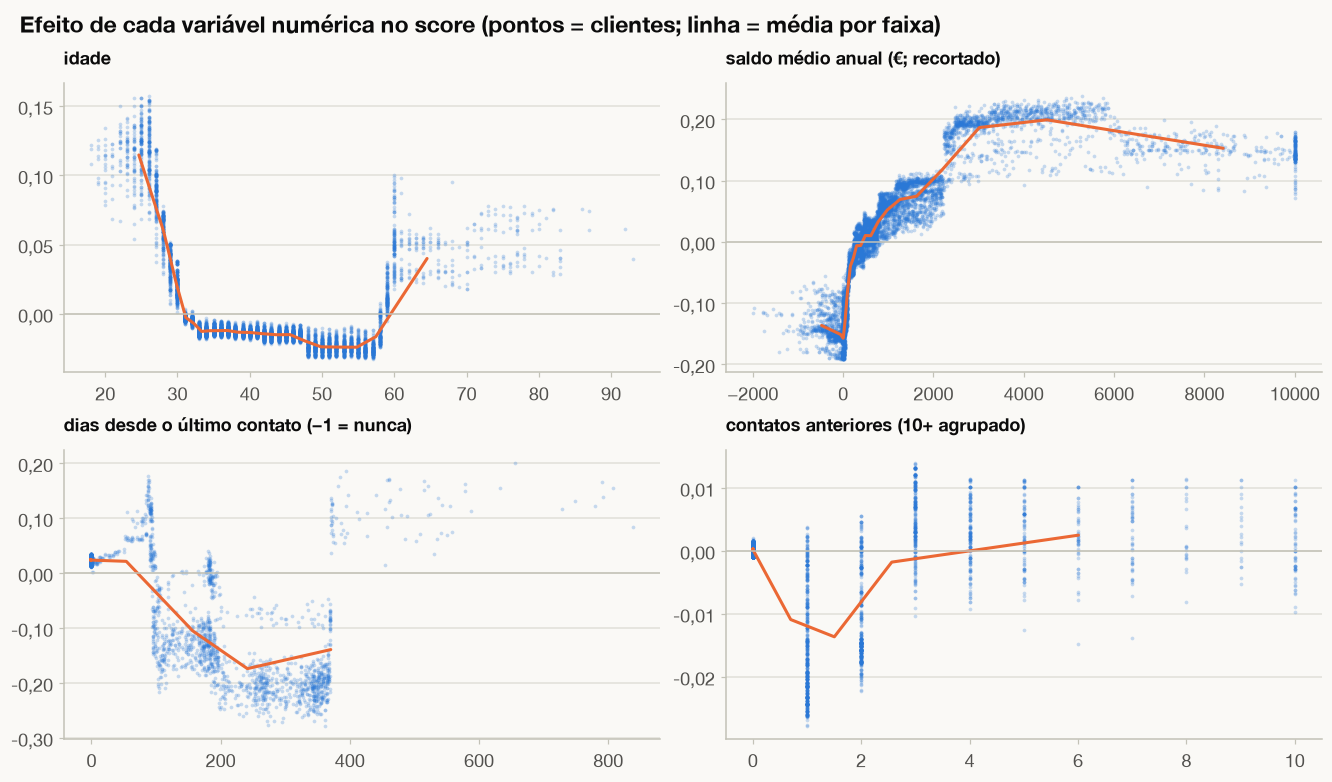

In [6]:
fig, axes = plots.new_figure(12, 7, nrows=2, ncols=2)
panels = [("age", test["age"], "idade"), ("balance", test["balance"].clip(-2000, 10000), "saldo médio anual (€; recortado)"),
          ("pdays", test["pdays"], "dias desde o último contato (−1 = nunca)"), ("previous", test["previous"].clip(upper=10), "contatos anteriores (10+ agrupado)")]
for ax, (var, values, title) in zip(axes.flat, panels):
    ax.scatter(values, contribs[var], s=6, alpha=0.25, color=BLUE, linewidths=0)
    bins = pd.qcut(values.rank(method="first"), 20, labels=False)
    trend = pd.DataFrame({"x": values, "y": contribs[var]}).groupby(bins).mean()
    ax.plot(trend["x"], trend["y"], color=ORANGE, linewidth=2)
    ax.axhline(0, color=BASELINE, linewidth=1)
    ax.set_title(title, fontsize=12)
    plots.decimal_axis(ax, "y", 2)
fig.suptitle("Efeito de cada variável numérica no score (pontos = clientes; linha = média por faixa)", x=0.01, ha="left",
             fontsize=15, fontweight="bold")
plots.save(fig, "int_dependencia")

**Variáveis numéricas**
- **Saldo:** mais saldo → mais propensão, subindo até ~€3 mil e estável depois; saldo zero ou negativo pesa
  contra.
- **pdays:** contato anterior há até ~3 meses ajuda. Entre ~4 e 12 meses pesa contra. Há poucos casos acima
  de 1 ano (quase todos de 2010), então não é uma leitura confiável.
- **Idade:** um U pequeno, positivo abaixo de ~30 e acima de ~60, de no máximo ~0,15 log-odds (≈1,16×). É bem
  menor que o efeito que aparece na base toda.
- **Contatos anteriores:** quase neutros depois que `poutcome` entra.

## 2. Efeitos dentro do mês na regressão logística

A logística com efeito fixo de mês dá uma segunda leitura, independente, das direções. Os coeficientes são
comparações **entre clientes do mesmo mês**, e `exp(coef)` é o multiplicador da chance (odds). Para
interpretar, usamos `C = 1`, com menos encolhimento que o `C = 0,1` do modelo de referência.

In [7]:
logistic = make_logistic(C=1.0).fit(train, train[TARGET])
coef = pd.Series(logistic[-1].coef_[0], index=logistic[:-1].get_feature_names_out())
contrasts = {
    "Sucesso na campanha anterior (vs. nunca contatado)": coef["poutcome_success"] - coef["poutcome_nonexistent"],
    "Fracasso na campanha anterior (vs. nunca contatado)": coef["poutcome_failure"] - coef["poutcome_nonexistent"],
    "Com crédito imobiliário": coef["housing_yes"],
    "Com empréstimo pessoal": coef["loan_yes"],
    "Crédito em inadimplência": coef["default_yes"],
    "Telefone fixo (vs. celular)": coef["contact_telephone"] - coef["contact_cellular"],
    "Canal não registrado (vs. celular)": coef["contact_unknown"] - coef["contact_cellular"],
    "18–25 anos (vs. 36–45)": coef["age_18-25"] - coef["age_36-45"],
    "66+ anos (vs. 36–45)": coef["age_66+"] - coef["age_36-45"],
    "Estudante (vs. blue-collar)": coef["job_student"] - coef["job_blue-collar"],
    "Aposentado (vs. blue-collar)": coef["job_retired"] - coef["job_blue-collar"],
    "Ensino superior (vs. secundário)": coef["education_tertiary"] - coef["education_secondary"],
    "Solteiro (vs. casado)": coef["marital_single"] - coef["marital_married"],
}
odds = pd.Series({k: float(np.exp(v)) for k, v in contrasts.items()}, name="odds ratio (dentro do mês)")
odds.sort_values(ascending=False).to_frame()

,odds ratio (dentro do mês)
Sucesso na campanha anterior (vs. nunca contatado),3.295
18–25 anos (vs. 36–45),1.393
Solteiro (vs. casado),1.284
Crédito em inadimplência,1.199
Aposentado (vs. blue-collar),1.156
66+ anos (vs. 36–45),1.123
Ensino superior (vs. secundário),1.082
Estudante (vs. blue-collar),0.851
Com empréstimo pessoal,0.820
Com crédito imobiliário,0.722


A logística confirma as direções do LightGBM com números de odds ratio **dentro do mês**:
- sucesso anterior **3,3×**;
- 18–25 anos **1,39×**;
- solteiro vs. casado **1,28×**;
- crédito imobiliário **0,72×**;
- empréstimo pessoal **0,82×**;
- telefone fixo vs. celular **0,67×**;
- fracasso anterior vs. nunca contatado **0,56×**;
- canal não registrado **0,26×**. Fora de mai–jun/2008, porém, há só 577 casos, então não é um achado
  confiável.

"Estudante" fica abaixo de blue-collar (0,85×) porque a faixa 18–25 já absorve o efeito da idade.
"Inadimplente" (1,20×) tem só 815 casos e não é um achado confiável.

## 3. Exemplos individuais: os "motivos" de cada cliente

Em produção, cada cliente da lista sai com os 3 fatores que mais empurram o seu score para cima. Isso ajuda o
operador a abrir a conversa e dá transparência para auditoria.

,motivo_1,motivo_2,motivo_3
43122,poutcome=success,pdays=92,age=20
6933,marital=single,pdays=-1,loan=no


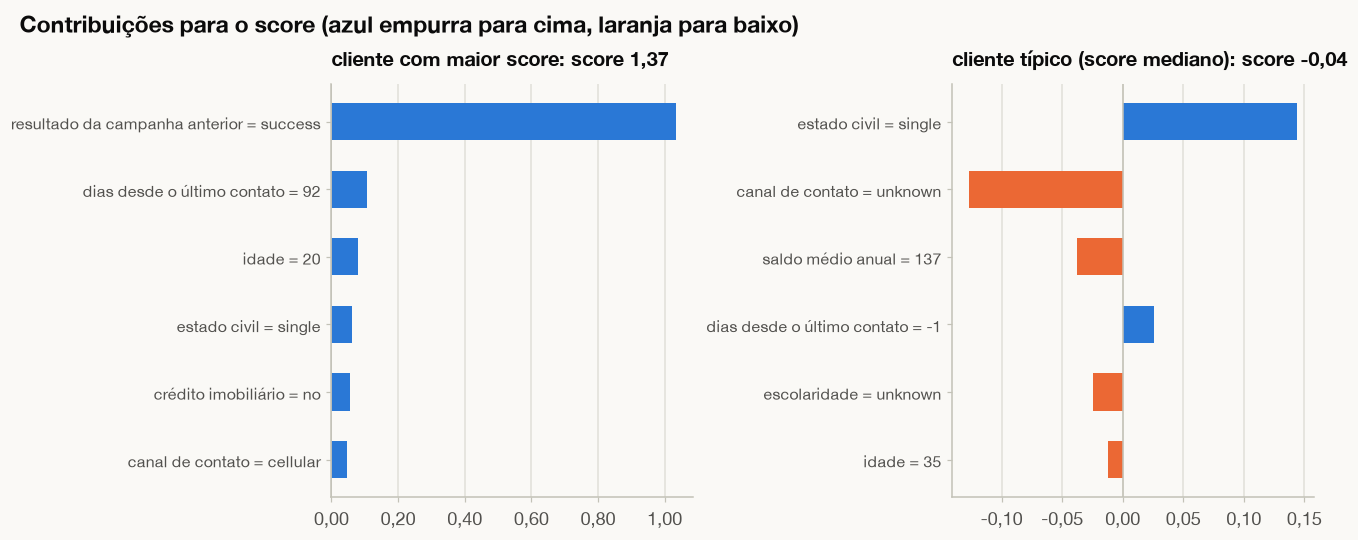

In [8]:
score = pd.Series(model.decision_function(test), index=test.index)
examples = {"cliente com maior score": score.idxmax(), "cliente típico (score mediano)": (score - score.median()).abs().idxmin()}
fig, axes = plots.new_figure(12, 4.8, ncols=2)
for ax, (title, idx) in zip(axes, examples.items()):
    row = contribs.loc[idx].drop("bias").sort_values(key=np.abs, ascending=False).head(6)[::-1]
    labels = [f"{LABELS[v]} = {test.loc[idx, v]}" for v in row.index]
    ax.barh(labels, row, color=[BLUE if v > 0 else ORANGE for v in row], height=0.55)
    ax.axvline(0, color=BASELINE, linewidth=1)
    ax.grid(axis="y", visible=False)
    ax.grid(axis="x", visible=True)
    plots.decimal_axis(ax, "x", 2)
    ax.set_title(f"{title}: score {plots.fmt_num(score[idx], 2)}", fontsize=13)
    ax.tick_params(axis="y", labelsize=10.5)
fig.suptitle("Contribuições para o score (azul empurra para cima, laranja para baixo)", x=0.01, ha="left",
             fontsize=15, fontweight="bold")
plots.save(fig, "int_exemplos")
reason_codes(contribs.loc[list(examples.values())], test.loc[list(examples.values())])

## 4. Insights acionáveis

| # | Insight | Evidência | Ação |
|---|---|---|---|
| 1 | **Sucesso anterior é o sinal mais forte** | 65% de conversão; 3,3× a chance dentro do mês | colocar no topo da lista; manter relacionamento pós-venda |
| 2 | **Endividamento reduz a propensão** | crédito imobiliário 0,72×; empréstimo pessoal 0,82×; saldo negativo 0,84× (lift no mês) | rebaixar na lista ou oferecer outro produto/mensagem |
| 3 | **Celular converte mais que fixo** | fixo 0,67× vs. celular, dentro do mês (associação observacional) | preferir celular e confirmar no A/B; o "canal não registrado" é quase todo artefato de mai–jun/2008 |
| 4 | **Recusa recente pesa contra** | fracasso anterior 0,56× vs. nunca contatado | respeitar um intervalo antes de reabordar |
| 5 | **Idade e profissão pesam pouco dentro do mês** | 60+: 1,07×; aposentado 1,06×; só 18–25 se destaca (1,2–1,4×) | não criar política por idade (era época; risco de conduta); idade fica fora dos motivos do operador |
| 6 | **Da 5ª ligação em diante o retorno cai** | no mesmo mês, tentativas 1–4 rendem ~1,0× e da 5ª em diante ~0,6×; limite de 4: −21,8% de ligações, −7,4% de adesões | limite padrão de 4, ajustado pela regra de custo por tentativa |
| 7 | **Quantos ligar depende do "clima" da campanha** | 2008: ligar para todos dava prejuízo e a regra liga para <1%; 2009: +22%; 2010: liga para todos | decidir pela regra de valor esperado **com a taxa esperada da campanha** |
| 8 | **Modelo vs. regra simples** | +0,056 de AUC no mês no hold-out; +0,028 em 2009–10; empate em 2010; no top 20%: 29,6% vs. 27,8% das adesões | ganho modesto: começar com o modelo e medir contra a regra num A/B |

## 5. Robustez no tempo: dois testes fora do tempo

O hold-out aleatório mistura meses. Aqui treinamos só com o passado e testamos no futuro:
- **(a)** treino mai/08–abr/09 → teste mai/09–nov/10. É um teste de extrapolação: o treino tem só 153 casos de
  `poutcome = success` e nenhum `pdays > 365`.
- **(b)** treino até dez/09 → teste 2010 (2.620 clientes).

A pergunta principal é se o modelo **continua ordenando bem dentro de cada mês**.

In [9]:
cuts = {"(a) até abr/09 → mai/09–nov/10": "2009-04", "(b) até dez/09 → 2010": "2009-12"}
oot_rows, oot_models = {}, {}
for label, end in cuts.items():
    tr, te = split_oot(df, train_end=end)
    for name, make in {"LightGBM ajustado": lambda: make_lgbm(**best_params),
                       "LightGBM sem ajuste do mês": lambda: make_lgbm_pooled(**best_params),
                       "Logística + efeito do mês": lambda: make_logistic(0.1),
                       "Regra de negócio": BusinessRule}.items():
        fitted = make().fit(tr, tr[TARGET])
        s = fitted.decision_function(te) if hasattr(fitted, "decision_function") else fitted.predict_proba(te)[:, 1]
        oot_rows[(label, name)] = {"AUC dentro do mês": group_auc(te[TARGET], s, te[PERIOD]),
                                   "lift@20% no mês": lift_at_k(te[TARGET], s, 0.2, te[PERIOD]),
                                   "n teste": len(te), "taxa treino": tr[TARGET].mean(), "taxa teste": te[TARGET].mean()}
        oot_models[(label, name)] = fitted
oot_table = pd.DataFrame(oot_rows).T
oot_table

AUC dentro do mês  \
(a) até abr/09 → mai/09–nov/10 LightGBM ajustado                       0.625   
                               LightGBM sem ajuste do mês              0.635   
                               Logística + efeito do mês               0.628   
                               Regra de negócio                        0.598   
(b) até dez/09 → 2010          LightGBM ajustado                       0.698   
                               LightGBM sem ajuste do mês              0.687   
                               Logística + efeito do mês               0.709   
                               Regra de negócio                        0.699   

                                                           lift@20% no mês  \
(a) até abr/09 → mai/09–nov/10 LightGBM ajustado                     1.428   
                               LightGBM sem ajuste do mês            1.282   
                               Logística + efeito do mês             1.420   
                               Regra de negócio                      1.505   
(b) até dez/09 → 2010          LightGBM ajustado                     1.520   
                               LightGBM sem ajuste do mês            1.509   
                               Logística + efeito do mês             1.502   
                               Regra de negócio                      1.510   

                                                            n teste  \
(a) até abr/09 → mai/09–nov/10 LightGBM ajustado          11034.000   
                               LightGBM sem ajuste do mês 11034.000   
                               Logística + efeito do mês  11034.000   
                               Regra de negócio           11034.000   
(b) até dez/09 → 2010          LightGBM ajustado           2620.000   
                               LightGBM sem ajuste do mês  2620.000   
                               Logística + efeito do mês   2620.000   
                               Regra de negócio            2620.000   

                                                           taxa treino  \
(a) até abr/09 → mai/09–nov/10 LightGBM ajustado                 0.066   
                               LightGBM sem ajuste do mês        0.066   
                               Logística + efeito do mês         0.066   
                               Regra de negócio                  0.066   
(b) até dez/09 → 2010          LightGBM ajustado                 0.092   
                               LightGBM sem ajuste do mês        0.092   
                               Logística + efeito do mês         0.092   
                               Regra de negócio                  0.092   

                                                           taxa teste  
(a) até abr/09 → mai/09–nov/10 LightGBM ajustado                0.274  
                               LightGBM sem ajuste do mês       0.274  
                               Logística + efeito do mês        0.274  
                               Regra de negócio                 0.274  
(b) até dez/09 → 2010          LightGBM ajustado                0.516  
                               LightGBM sem ajuste do mês       0.516  
                               Logística + efeito do mês        0.516  
                               Regra de negócio                 0.516

In [10]:
oot_boot = {}
for label, end in cuts.items():
    _, te = split_oot(df, train_end=end)
    s = {name: oot_models[(label, name)].decision_function(te) for name in ["LightGBM ajustado", "Logística + efeito do mês", "Regra de negócio"]}
    for a, b in [("LightGBM ajustado", "Logística + efeito do mês"), ("LightGBM ajustado", "Regra de negócio"),
                 ("Logística + efeito do mês", "Regra de negócio")]:
        oot_boot[f"{label}: {a} − {b}"] = paired_bootstrap(te[TARGET], s[a], s[b], group_auc, n_boot=500,
                                                            groups=te[PERIOD].to_numpy())
pd.DataFrame(oot_boot).T

,diff,ci_low,ci_high
(a) até abr/09 → mai/09–nov/10: LightGBM ajustado − Logística + efeito do mês,-0.003,-0.013,0.007
(a) até abr/09 → mai/09–nov/10: LightGBM ajustado − Regra de negócio,0.028,0.006,0.050
(a) até abr/09 → mai/09–nov/10: Logística + efeito do mês − Regra de negócio,0.031,0.013,0.049
(b) até dez/09 → 2010: LightGBM ajustado − Logística + efeito do mês,-0.010,-0.020,0.000
(b) até dez/09 → 2010: LightGBM ajustado − Regra de negócio,-0.000,-0.014,0.014
(b) até dez/09 → 2010: Logística + efeito do mês − Regra de negócio,0.010,-0.001,0.022


**Fora do tempo:**
- o modelo **continua ordenando** dentro do mês (AUC 0,63 em (a) e 0,70 em (b)), até melhor que no hold-out,
  porque 2009–2010 tem mais clientes com histórico, e o histórico é o sinal mais forte;
- LightGBM e logística **empatam** (diferenças de −0,003 e −0,010, com intervalos que incluem ou tocam o zero);
- contra a regra, os modelos ganham em (a) (+0,028 [0,006; 0,050]) e **empatam em 2010**. Quando quase todos
  têm histórico, "sucesso anterior primeiro" já captura o essencial;
- **o ajuste do mês não melhora a ordenação fora do tempo**: sem ele, 0,635 em (a) e 0,687 em (b), contra
  0,625 e 0,698 com ele. O ganho do ajuste é a decomposição clima × cliente e evitar o atalho da idade (seção 1).

**Decisão:** o LightGBM continua sendo o modelo entregue. Foi escolhido pelo critério definido antes (CV), foi
significativamente melhor no hold-out e gera explicações exatas por cliente. A logística fica como
**desafiante** e alternativa explicável, e o A/B contra a regra mede o ganho real.

,auc,n,positivos,taxa
2009-05,0.632,5575,533,0.096
2009-06,0.571,642,241,0.375
2009-07,0.532,207,76,0.367
2009-08,0.524,772,264,0.342
2009-09,0.631,282,123,0.436
2009-10,0.555,438,184,0.420
2009-11,0.615,297,147,0.495
2009-12,0.580,201,99,0.493
2010-01,0.619,227,104,0.458
2010-02,0.623,353,186,0.527


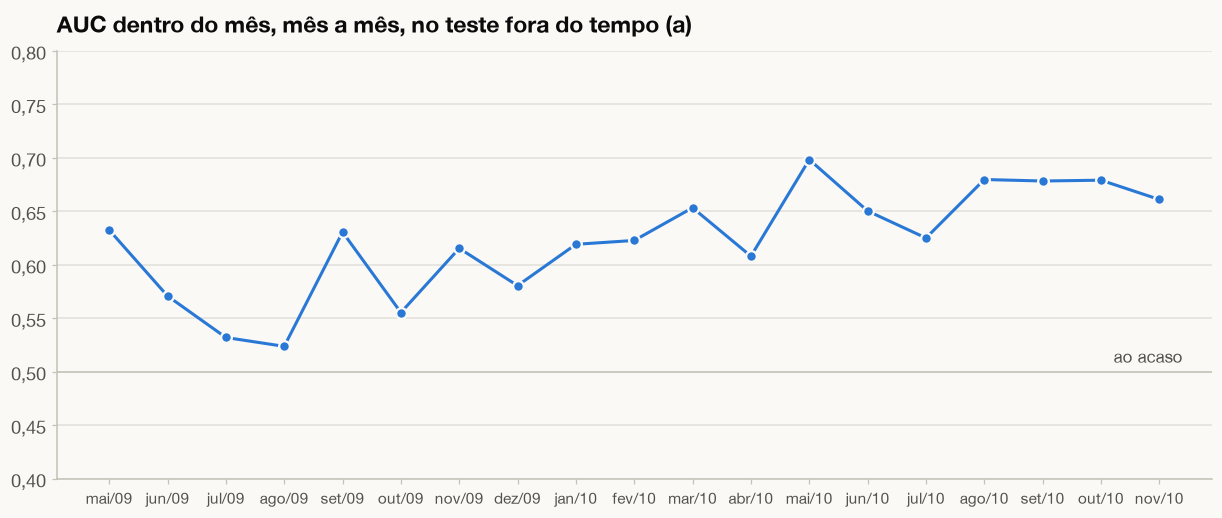

In [11]:
label_a = list(cuts)[0]
tr_a, te_a = split_oot(df, train_end=cuts[label_a])
lgbm_a = oot_models[(label_a, "LightGBM ajustado")]
score_a = pd.Series(lgbm_a.decision_function(te_a), index=te_a.index)
monthly = pd.DataFrame.from_dict({
    period: {"auc": group_auc(g[TARGET], score_a[g.index], g[PERIOD]), "n": len(g), "positivos": int(g[TARGET].sum()),
             "taxa": g[TARGET].mean()}
    for period, g in te_a.groupby(PERIOD) if g[TARGET].nunique() == 2
}, orient="index")
monthly_ok = monthly[(monthly["positivos"] >= 30) & (monthly["n"] - monthly["positivos"] >= 30)]

fig, ax = plots.new_figure(11, 4.6)
x = np.arange(len(monthly_ok))
ax.plot(x, monthly_ok["auc"], color=BLUE, marker="o", markeredgecolor=plots.SURFACE, markeredgewidth=1.5)
ax.axhline(0.5, color=BASELINE, linewidth=1)
ax.text(len(x) - 0.6, 0.505, "ao acaso", color=INK_2, fontsize=11, ha="right", va="bottom")
ax.set_xticks(x, [plots.period_label(p) for p in monthly_ok.index], fontsize=10)
plots.decimal_axis(ax, "y", 2)
ax.set_ylim(0.4, 0.8)
ax.set_title("AUC dentro do mês, mês a mês, no teste fora do tempo (a)")
plots.save(fig, "oot_auc_mensal")
monthly_ok

Mês a mês, a AUC dentro do mês fica entre ~0,52 e ~0,70, mais fraca no meio de 2009 e mais forte em 2010.
É esse o gráfico que o monitoramento acompanharia em produção.

## 6. Probabilidade em campanhas novas: ajuste pela taxa esperada

O score ordena. A **probabilidade** precisa saber em que "clima" a campanha acontece: a taxa-base mudou de 5%
para 50%. Para cada campanha (mês), escolhemos um único deslocamento do score que faz a média das
probabilidades do lote bater com a taxa esperada (`calibrate_to_rate`). A ordem não muda, e um lote com
clientes melhores que a média do treino não é superestimado. Em produção a taxa do mês ainda não é conhecida,
então comparamos três estimativas, no teste (a):
- **sem ajuste:** usa a taxa média do treino (6,6%);
- **taxa do mês anterior:** a melhor estimativa disponível na prática;
- **taxa real do mês:** referência inalcançável.

Com premissas C = €10 e V = €100, cada versão alimenta a regra `p ≥ C/V` e comparamos o resultado com "ligar
para todos" e com o corte fixo top 20%.

In [12]:
rate_by_month = df.groupby(PERIOD)[TARGET].mean()
months_sorted = list(rate_by_month.index)
previous_rate = {m: rate_by_month[months_sorted[i - 1]] for i, m in enumerate(months_sorted) if i > 0}
base_rates = {
    "sem ajuste (taxa média do treino)": pd.Series(tr_a[TARGET].mean(), index=te_a.index),
    "taxa do mês anterior": te_a[PERIOD].map(previous_rate),
    "taxa real do mês (referência)": te_a[PERIOD].map(rate_by_month),
}
C_CLIENT, V_SUBSCRIPTION = 10.0, 100.0
y_a = te_a[TARGET]
pct_a = score_a.groupby(te_a[PERIOD]).rank(pct=True, ascending=False, method="first")


def result_per_1000(called):
    return 1000 * (V_SUBSCRIPTION * y_a[called].sum() - C_CLIENT * called.sum()) / len(y_a)


def calibrate_by_month(score, periods, rates):
    """Per month, one offset so the month's batch converts at the given expected rate."""
    p = pd.Series(np.nan, index=score.index)
    for month, idx in score.groupby(periods).groups.items():
        p[idx] = calibrate_to_rate(score[idx], rates[idx].iloc[0])
    return p


prior_rows = {}
for name, rate in base_rates.items():
    p = calibrate_by_month(score_a, te_a[PERIOD], rate)
    called = p >= C_CLIENT / V_SUBSCRIPTION
    prior_rows[f"p ≥ C/V com {name}"] = {"Brier": brier_score_loss(y_a, p), "prob. média": p.mean(),
                                         "fração ligada": called.mean(), "resultado por 1.000 (€)": result_per_1000(called)}
prior_rows["ligar para todos"] = {"fração ligada": 1.0, "resultado por 1.000 (€)": result_per_1000(pd.Series(True, index=y_a.index))}
prior_rows["top 20% de cada mês"] = {"fração ligada": 0.2, "resultado por 1.000 (€)": result_per_1000(pct_a <= 0.2)}
prior_table = pd.DataFrame(prior_rows).T
print(f"taxa real no teste (a): {plots.fmt_pct(y_a.mean(), 1)} | taxa média do treino: {plots.fmt_pct(tr_a[TARGET].mean(), 1)}")
prior_table

taxa real no teste (a): 27,4% | taxa média do treino: 6,6%


,Brier,prob. média,fração ligada,resultado por 1.000 (€)
p ≥ C/V com sem ajuste (taxa média do treino),0.238,0.066,0.146,5399.674
p ≥ C/V com taxa do mês anterior,0.167,0.291,0.849,16879.645
p ≥ C/V com taxa real do mês (referência),0.159,0.274,0.708,18433.931
ligar para todos,NaN,NaN,1.000,17360.885
top 20% de cada mês,NaN,NaN,0.200,5764.908


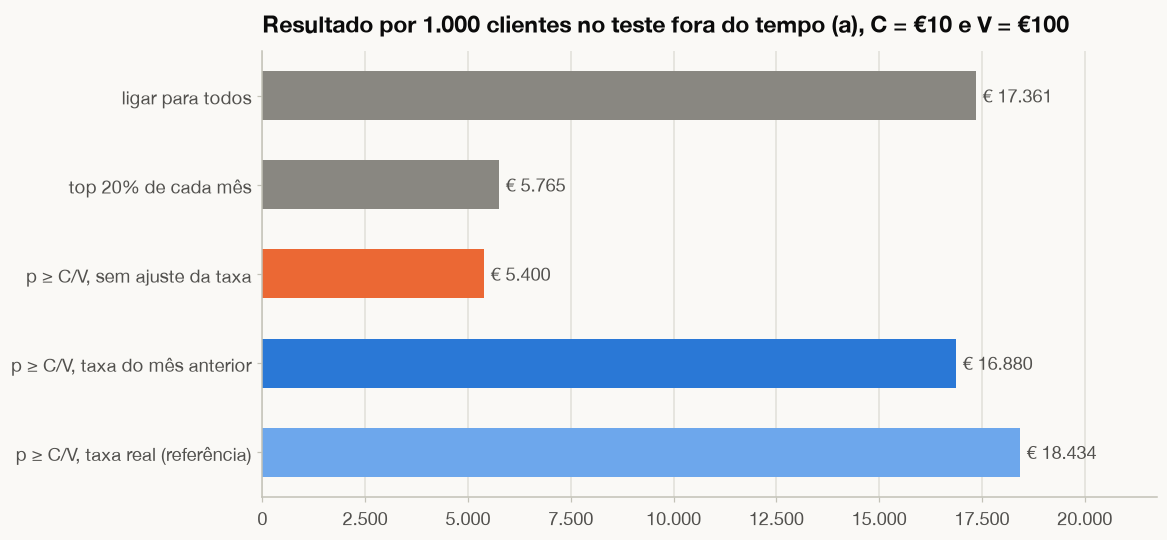

In [13]:
fig, ax = plots.new_figure(10.5, 4.8)
order = ["ligar para todos", "top 20% de cada mês", "p ≥ C/V com sem ajuste (taxa média do treino)",
         "p ≥ C/V com taxa do mês anterior", "p ≥ C/V com taxa real do mês (referência)"]
short = ["ligar para todos", "top 20% de cada mês", "p ≥ C/V, sem ajuste da taxa",
         "p ≥ C/V, taxa do mês anterior", "p ≥ C/V, taxa real (referência)"]
values = prior_table.loc[order, "resultado por 1.000 (€)"]
colors = [GRAY, GRAY, ORANGE, BLUE, plots.BLUE_RAMP[2]]
ax.barh(short[::-1], values[::-1], color=colors[::-1], height=0.55)
for i, v in enumerate(values[::-1]):
    ax.text(v + 150, i, f"€ {plots.fmt_num(v)}", va="center", fontsize=12, color=INK_2)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
plots.thousands_axis(ax, "x")
ax.set_xlim(0, values.max() * 1.18)
ax.set_title("Resultado por 1.000 clientes no teste fora do tempo (a), C = €10 e V = €100")
plots.save(fig, "oot_ajuste_taxa")

**O ajuste pela taxa esperada é o que faz a regra de custo funcionar fora do tempo.** No período (a) a taxa
real foi 27,4%, contra 6,6% no treino.
- **Sem ajuste**, as probabilidades ficam ~4× abaixo da realidade (média de 6,6%). A regra liga para só 15% e
  **perde ~69% do resultado**: €5,4 mil contra €17,4 mil de ligar para todos.
- **Com a taxa do mês anterior**, que é uma estimativa simples e disponível, o Brier cai de 0,238 para 0,167 e
  o resultado vai a **€16,9 mil**. Isso fica perto de ligar para todos (€17,4 mil), que é o certo num período
  quente; com a taxa real seria €18,4 mil. O erro na estimativa da taxa custa ~3%, e não estimá-la custa ~69%.
- O corte fixo top 20% rende só €5,8 mil nesse período quente: capacidade limitada custa caro quando quase
  todos convertem.

**Na prática:** o modelo ordena; a taxa-base da campanha é um parâmetro de negócio re-estimado a cada ciclo; a
decisão de quantos ligar sai de `p ≥ C/V`, limitada pela capacidade do call center.

## 7. Estabilidade das variáveis (PSI)

O *Population Stability Index* compara a distribuição de cada variável entre o treino e o período novo.
Regra usual: < 0,10 estável; 0,10–0,25 atenção; > 0,25 mudança relevante. Aqui comparamos 2008 com 2010.

In [14]:
d08, d10 = df[df["year"] == 2008], df[df["year"] == 2010]
psi_vars = ["age", "balance", "job", "marital", "education", "housing", "loan", "contact", "poutcome", "contacted_before"]
psi_table = pd.Series({v: psi(d08[v], d10[v]) for v in psi_vars}, name="PSI 2008 → 2010").sort_values(ascending=False)
score_psi = psi(pd.Series(model.decision_function(d08)), pd.Series(model.decision_function(d10)))
print(f"PSI do score do modelo 2008 → 2010: {score_psi:.2f}")
psi_table.to_frame().assign(nivel=lambda t: pd.cut(t.iloc[:, 0], [-1, 0.1, 0.25, 99], labels=["estável", "atenção", "mudança"]))

PSI do score do modelo 2008 → 2010: 0.63


,PSI 2008 → 2010,nivel
poutcome,2.996,mudança
contacted_before,2.511,mudança
contact,0.765,mudança
job,0.618,mudança
housing,0.548,mudança
age,0.377,mudança
balance,0.258,mudança
loan,0.156,atenção
marital,0.098,estável
education,0.081,estável


**A população mudou muito entre 2008 e 2010**: `poutcome` e `contacted_before` (PSI 3,0 e 2,5), canal,
profissão, crédito imobiliário e idade. O próprio score tem PSI 0,63. Com monitoramento de PSI esse
deslocamento dispara um alerta e, com ele, uma reavaliação, mesmo antes de o resultado das ligações chegar.

## 8. Demonstração: a lista de ligações

O mesmo código da linha de comando (`python -m bank_marketing.predict`) aplicado a uma "campanha" ilustrativa:
os clientes de novembro/2010. A maioria deles estava no treino, então isto mostra o formato da saída, não
desempenho. A taxa esperada vem do mês anterior, e a idade nunca aparece como motivo para o operador.

In [15]:
campaign = df[df[PERIOD] == "2010-11"].drop(columns=[TARGET])
expected_rate = previous_rate["2010-11"]
call_list = score_batch(model, campaign, top=0.2, base_rate=expected_rate, reasons=3).sort_values("rank")
print(f"{len(call_list)} clientes; taxa esperada {plots.fmt_pct(expected_rate, 1)}; "
      f"{int(call_list['priority'].sum())} marcados como prioridade (top 20%)")
call_list.head(8)

75 clientes; taxa esperada 40,9%; 15 marcados como prioridade (top 20%)


,row_id,score,rank,decile,priority,probability,motivo_1,motivo_2,motivo_3
26,45162,1.325,1,1,True,0.627,poutcome=success,pdays=91,marital=single
19,45155,1.320,2,1,True,0.626,poutcome=success,pdays=91,housing=no
39,45175,1.313,3,1,True,0.624,poutcome=success,balance=2543,pdays=93
38,45174,1.307,4,1,True,0.623,poutcome=success,pdays=92,housing=no
49,45185,1.291,5,1,True,0.619,poutcome=success,balance=4256,pdays=92
65,45201,1.280,6,1,True,0.616,poutcome=success,housing=no,contact=cellular
72,45208,1.277,7,1,True,0.616,poutcome=success,balance=5715,housing=no
14,45150,1.261,8,1,True,0.612,poutcome=success,balance=2352,housing=no


Os primeiros da lista são clientes com **sucesso anterior**, contato recente (`pdays` ~90), saldo positivo e
sem crédito imobiliário. Os motivos saem prontos para o operador.

## 9. Como colocar em produção

**Fluxo (lote, antes de cada ciclo de campanha)**

`CRM/DW → features (mesmo código src/) → modelo versionado → score + motivos → lista priorizada no discador → resultado das ligações → monitoramento → retreino`

| Tema | Proposta |
|---|---|
| Modo | **Batch**: a campanha é planejada, não há necessidade de tempo real. Uma API (FastAPI) só se o discador pedir score sob demanda |
| Decisão | ordenar pelo score; ligar enquanto `p ≥ C/V`, com `p` ajustado à taxa esperada (ex.: mês anterior); limitado pela capacidade; **no máximo 3 tentativas** |
| Artefato | `model.joblib` + `metadata.json` (features, hiperparâmetros, hash dos dados, versões, métricas); registro de modelos (ex.: MLflow) |
| Monitoramento | PSI das variáveis e do score a cada lote; AUC e lift dentro do mês quando o resultado chega; calibração (prevista vs. observada) por campanha |
| Retreino | periódico (ex.: trimestral) ou por gatilho: PSI > 0,25, AUC no mês em janela móvel de 3 meses < 0,58 (um mês isolado oscila muito) ou calibração fora de ±5 p.p. |
| Experimento | **A/B com grupo de controle aleatório** (ex.: 10% da lista ligados ao acaso). Mede o ganho incremental e alimenta o retreino sem viés; champion/challenger (logística vs. LightGBM) |
| Viés de seleção | só observamos quem foi ligado. A fatia aleatória é o que permite aprender com clientes fora da política atual |
| Governança | LGPD (base legal, opt-out, "Não Me Perturbe"); suitability do produto; risco de conduta com idosos: a idade tem efeito pequeno (removê-la custa ~0,004 de AUC no mês) e nunca aparece como motivo; motivos por cliente para auditoria |
| Próximos passos | variáveis macro do `bank-additional` (Euribor, emprego) para modelar o "clima"; modelo de *uplift* (quem adere *por causa* da ligação); custos e margens reais no lugar das premissas |

In [16]:
save_metrics("interpretation", {
    "importance_mean_abs_shap": importance.sort_values(ascending=False).to_dict(),
    "odds_ratios_within_month": odds.to_dict(),
    "category_contributions": {k: {kk: float(vv) for kk, vv in v.items()} for k, v in direction.items()},
})
save_metrics("oot", {
    "table": {f"{a} | {b}": {k: float(v) for k, v in row.items()} for (a, b), row in oot_table.iterrows()},
    "bootstrap_group_auc": oot_boot,
    "monthly_auc_cut_a": {k: float(v) for k, v in monthly_ok["auc"].items()},
    "prior_shift_cut_a": {k: {kk: float(vv) for kk, vv in row.dropna().items()} for k, row in prior_table.iterrows()},
})
save_metrics("shap_month_adjustment", {k: {kk: float(vv) for kk, vv in row.items()} for k, row in compare.iterrows()})
save_metrics("psi", {"features_2008_to_2010": psi_table.to_dict(), "score_2008_to_2010": score_psi})
print("seções interpretation, oot e psi salvas em reports/metrics.json")

seções interpretation, oot e psi salvas em reports/metrics.json
